In [1]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 94.2 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.10
    Uninstalling idna-3.10:
      Successfully uninstalled idna-3.10


In [ ]:
import os
import cv2
import numpy as np
import shutil
from ultralytics import YOLO
from tqdm import tqdm

# ==============================================================================
# CẤU HÌNH - BẠN HÃY THAY ĐỔI CÁC GIÁ TRỊ NÀY
# ==============================================================================
# Đường dẫn đến mô hình YOLO (.pt) đã huấn luyện của bạn
YOLO_MODEL_PATH = "/content/drive/MyDrive/data/yolo_kaggle/best (1).pt"

# Đường dẫn đến thư mục CHA chứa các thư mục con (01, 02, 03, 04,...)
INPUT_DIR = "/content/drive/MyDrive/data/test_vn/test_VN" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Đường dẫn đến thư mục CHA mà bạn muốn lưu kết quả
OUTPUT_PARENT_DIR = "/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_test_vn" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Liệt kê tên các thư mục con chứa ảnh KHỎE MẠNH
HEALTHY_FOLDER_NAMES = ['04']

# Ngưỡng tin cậy để giữ lại một bounding box
CONFIDENCE_THRESHOLD = 0.25

# ==============================================================================
# HÀM XỬ LÝ MỚI: CẮT VÀ LƯU ẢNH
# ==============================================================================

def crop_and_save_boxes(image, boxes, output_folder, base_filename):
    """
    Cắt các vùng ảnh dựa trên bounding boxes và lưu thành các file riêng biệt.
    Mỗi box sẽ được lưu thành một file mới.
    """
    if len(boxes) == 0:
        return 0 # Không có box nào để lưu

    count = 0
    base_name, ext = os.path.splitext(base_filename)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box[:4])

        # Cắt ảnh theo tọa độ của box
        cropped_image = image[y1:y2, x1:x2]

        # Kiểm tra xem ảnh cắt có kích thước hợp lệ không
        if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
            # Tạo tên file mới cho mỗi box, ví dụ: image_01_box_0.jpg, image_01_box_1.jpg
            new_filename = f"{base_name}_box_{i}{ext}"
            save_path = os.path.join(output_folder, new_filename)
            cv2.imwrite(save_path, cropped_image)
            count += 1
    return count

# ==============================================================================
# HÀM CHÍNH ĐỂ XỬ LÝ HÀNG LOẠT
# ==============================================================================

def process_all_folders_smart():
    """
    Hàm chính để duyệt qua tất cả các thư mục, phát hiện đối tượng bằng YOLO,
    cắt các đối tượng đó ra và lưu vào thư mục mới.
    """
    print("Bắt đầu quy trình xử lý tổng hợp (chế độ CẮT ẢNH)...")

    # Tải mô hình YOLO
    try:
        print(f"Đang tải mô hình YOLO từ: {YOLO_MODEL_PATH}")
        model = YOLO(YOLO_MODEL_PATH)
    except Exception as e:
        print(f"[Lỗi] Không thể tải mô hình YOLO: {e}")
        return

    # Tạo thư mục đầu ra chính
    os.makedirs(OUTPUT_PARENT_DIR, exist_ok=True)
    print(f"Kết quả sẽ được lưu tại: '{OUTPUT_PARENT_DIR}'")

    subfolders = [f for f in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, f))]
    if not subfolders:
        print(f"[Lỗi] Không tìm thấy thư mục con nào trong '{INPUT_DIR}'")
        return

    for folder_name in sorted(subfolders):
        input_folder_path = os.path.join(INPUT_DIR, folder_name)
        # Tạo thư mục con tương ứng trong thư mục output
        output_subfolder = os.path.join(OUTPUT_PARENT_DIR, folder_name)
        os.makedirs(output_subfolder, exist_ok=True)

        image_files = [f for f in os.listdir(input_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if folder_name in HEALTHY_FOLDER_NAMES:
            print(f"\nThư mục '{folder_name}' là thư mục khỏe mạnh. Tiến hành sao chép file...")
            for filename in tqdm(image_files, desc=f"Sao chép '{folder_name}'"):
                source_path = os.path.join(input_folder_path, filename)
                dest_path = os.path.join(output_subfolder, filename)
                shutil.copy(source_path, dest_path)
        else:
            print(f"\nĐang xử lý thư mục bệnh: '{folder_name}'")
            for filename in tqdm(image_files, desc=f"Xử lý '{folder_name}'"):
                image_path = os.path.join(input_folder_path, filename)
                name, ext = os.path.splitext(filename)

                try:
                    original_image = cv2.imread(image_path)
                    if original_image is None:
                        print(f"Cảnh báo: Không thể đọc file {image_path}, bỏ qua.")
                        continue

                    # BƯỚC 1: DỰ ĐOÁN THÔNG THƯỜNG
                    results_standard = model(original_image, conf=CONFIDENCE_THRESHOLD, verbose=False)
                    boxes_standard = results_standard[0].boxes.data.cpu().numpy()

                    if len(boxes_standard) > 0:
                        # THÀNH CÔNG: Cắt và lưu các box tìm được
                        crop_and_save_boxes(original_image, boxes_standard, output_subfolder, filename)
                    else:
                        # THẤT BẠI: Chuyển sang chế độ giải cứu
                        height, width, _ = original_image.shape
                        mid_point_y = height // 2
                        top_half = original_image[:mid_point_y, :]
                        bottom_half = original_image[mid_point_y:, :]

                        # Xử lý nửa trên
                        results_top = model(top_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
                        boxes_top = results_top[0].boxes.data.cpu().numpy()
                        if len(boxes_top) > 0:
                            crop_and_save_boxes(top_half, boxes_top, output_subfolder, f"{name}_top{ext}")

                        # Xử lý nửa dưới
                        results_bottom = model(bottom_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
                        boxes_bottom = results_bottom[0].boxes.data.cpu().numpy()
                        if len(boxes_bottom) > 0:
                            crop_and_save_boxes(bottom_half, boxes_bottom, output_subfolder, f"{name}_bottom{ext}")

                except Exception as e:
                    print(f"\n[Lỗi] Xảy ra lỗi khi xử lý file {filename}: {e}")

    print("\n======================================")
    print("HOÀN TẤT TOÀN BỘ QUÁ TRÌNH XỬ LÝ!")
    print("======================================")


# ==============================================================================
# ĐIỂM BẮT ĐẦU CHẠY CHƯƠNG TRÌNH
# ==============================================================================
if __name__ == "__main__":
    # Bạn có thể cần chạy dòng này trong Colab nếu chưa có thư viện tqdm
    # !pip install tqdm
    process_all_folders_smart()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Bắt đầu quy trình xử lý tổng hợp (chế độ CẮT ẢNH)...
Đang tải mô hình YOLO từ: /content/drive/MyDrive/data/yolo_kaggle/best (1).pt
Kết quả sẽ được lưu tại: '/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_test_vn'

Đang xử lý thư mục bệnh: '01'


Xử lý '01': 100%|██████████| 13/13 [00:07<00:00,  1.77it/s]



Đang xử lý thư mục bệnh: '02'


Xử lý '02': 100%|██████████| 20/20 [00:12<00:00,  1.63it/s]



Đang xử lý thư mục bệnh: '03'


Xử lý '03': 100%|██████████| 16/16 [00:08<00:00,  1.84it/s]



Thư mục '04' là thư mục khỏe mạnh. Tiến hành sao chép file...


Sao chép '04': 100%|██████████| 19/19 [00:03<00:00,  5.77it/s]


HOÀN TẤT TOÀN BỘ QUÁ TRÌNH XỬ LÝ!


In [ ]:
import os
import cv2
import numpy as np
import shutil
from ultralytics import YOLO
from tqdm import tqdm

# ==============================================================================
# CẤU HÌNH - BẠN HÃY THAY ĐỔI CÁC GIÁ TRỊ NÀY
# ==============================================================================
# Đường dẫn đến mô hình YOLO (.pt) đã huấn luyện của bạn
YOLO_MODEL_PATH = "/content/drive/MyDrive/data/yolo_kaggle/best (1).pt"

# Đường dẫn đến thư mục CHA chứa các thư mục con (01, 02, 03, 04,...)
INPUT_DIR = "/content/drive/MyDrive/data/data2/data_2" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Đường dẫn đến thư mục CHA mà bạn muốn lưu kết quả
OUTPUT_PARENT_DIR = "/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_02" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Liệt kê tên các thư mục con chứa ảnh KHỎE MẠNH
HEALTHY_FOLDER_NAMES = ['04']

# Ngưỡng tin cậy để giữ lại một bounding box
CONFIDENCE_THRESHOLD = 0.25

# ==============================================================================
# HÀM XỬ LÝ MỚI: CẮT VÀ LƯU ẢNH
# ==============================================================================

def crop_and_save_boxes(image, boxes, output_folder, base_filename):
    """
    Cắt các vùng ảnh dựa trên bounding boxes và lưu thành các file riêng biệt.
    Mỗi box sẽ được lưu thành một file mới.
    """
    if len(boxes) == 0:
        return 0 # Không có box nào để lưu

    count = 0
    base_name, ext = os.path.splitext(base_filename)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box[:4])

        # Cắt ảnh theo tọa độ của box
        cropped_image = image[y1:y2, x1:x2]

        # Kiểm tra xem ảnh cắt có kích thước hợp lệ không
        if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
            # Tạo tên file mới cho mỗi box, ví dụ: image_01_box_0.jpg, image_01_box_1.jpg
            new_filename = f"{base_name}_box_{i}{ext}"
            save_path = os.path.join(output_folder, new_filename)
            cv2.imwrite(save_path, cropped_image)
            count += 1
    return count

# ==============================================================================
# HÀM CHÍNH ĐỂ XỬ LÝ HÀNG LOẠT
# ==============================================================================

def process_all_folders_smart():
    """
    Hàm chính để duyệt qua tất cả các thư mục, phát hiện đối tượng bằng YOLO,
    cắt các đối tượng đó ra và lưu vào thư mục mới.
    """
    print("Bắt đầu quy trình xử lý tổng hợp (chế độ CẮT ẢNH)...")

    # Tải mô hình YOLO
    try:
        print(f"Đang tải mô hình YOLO từ: {YOLO_MODEL_PATH}")
        model = YOLO(YOLO_MODEL_PATH)
    except Exception as e:
        print(f"[Lỗi] Không thể tải mô hình YOLO: {e}")
        return

    # Tạo thư mục đầu ra chính
    os.makedirs(OUTPUT_PARENT_DIR, exist_ok=True)
    print(f"Kết quả sẽ được lưu tại: '{OUTPUT_PARENT_DIR}'")

    subfolders = [f for f in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, f))]
    if not subfolders:
        print(f"[Lỗi] Không tìm thấy thư mục con nào trong '{INPUT_DIR}'")
        return

    for folder_name in sorted(subfolders):
        input_folder_path = os.path.join(INPUT_DIR, folder_name)
        # Tạo thư mục con tương ứng trong thư mục output
        output_subfolder = os.path.join(OUTPUT_PARENT_DIR, folder_name)
        os.makedirs(output_subfolder, exist_ok=True)

        image_files = [f for f in os.listdir(input_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if folder_name in HEALTHY_FOLDER_NAMES:
            print(f"\nThư mục '{folder_name}' là thư mục khỏe mạnh. Tiến hành sao chép file...")
            for filename in tqdm(image_files, desc=f"Sao chép '{folder_name}'"):
                source_path = os.path.join(input_folder_path, filename)
                dest_path = os.path.join(output_subfolder, filename)
                shutil.copy(source_path, dest_path)
        else:
            print(f"\nĐang xử lý thư mục bệnh: '{folder_name}'")
            for filename in tqdm(image_files, desc=f"Xử lý '{folder_name}'"):
                image_path = os.path.join(input_folder_path, filename)
                name, ext = os.path.splitext(filename)

                try:
                    original_image = cv2.imread(image_path)
                    if original_image is None:
                        print(f"Cảnh báo: Không thể đọc file {image_path}, bỏ qua.")
                        continue

                    # BƯỚC 1: DỰ ĐOÁN THÔNG THƯỜNG
                    results_standard = model(original_image, conf=CONFIDENCE_THRESHOLD, verbose=False)
                    boxes_standard = results_standard[0].boxes.data.cpu().numpy()

                    if len(boxes_standard) > 0:
                        # THÀNH CÔNG: Cắt và lưu các box tìm được
                        crop_and_save_boxes(original_image, boxes_standard, output_subfolder, filename)
                    else:
                        # THẤT BẠI: Chuyển sang chế độ giải cứu
                        height, width, _ = original_image.shape
                        mid_point_y = height // 2
                        top_half = original_image[:mid_point_y, :]
                        bottom_half = original_image[mid_point_y:, :]

                        # Xử lý nửa trên
                        results_top = model(top_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
                        boxes_top = results_top[0].boxes.data.cpu().numpy()
                        if len(boxes_top) > 0:
                            crop_and_save_boxes(top_half, boxes_top, output_subfolder, f"{name}_top{ext}")

                        # Xử lý nửa dưới
                        results_bottom = model(bottom_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
                        boxes_bottom = results_bottom[0].boxes.data.cpu().numpy()
                        if len(boxes_bottom) > 0:
                            crop_and_save_boxes(bottom_half, boxes_bottom, output_subfolder, f"{name}_bottom{ext}")

                except Exception as e:
                    print(f"\n[Lỗi] Xảy ra lỗi khi xử lý file {filename}: {e}")

    print("\n======================================")
    print("HOÀN TẤT TOÀN BỘ QUÁ TRÌNH XỬ LÝ!")
    print("======================================")


# ==============================================================================
# ĐIỂM BẮT ĐẦU CHẠY CHƯƠNG TRÌNH
# ==============================================================================
if __name__ == "__main__":
    # Bạn có thể cần chạy dòng này trong Colab nếu chưa có thư viện tqdm
    # !pip install tqdm
    process_all_folders_smart()

Bắt đầu quy trình xử lý tổng hợp (chế độ CẮT ẢNH)...
Đang tải mô hình YOLO từ: /content/drive/MyDrive/data/yolo_kaggle/best (1).pt
Kết quả sẽ được lưu tại: '/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_02'

Đang xử lý thư mục bệnh: '01'


Xử lý '01': 100%|██████████| 637/637 [00:44<00:00, 14.37it/s]



Đang xử lý thư mục bệnh: '02'


Xử lý '02': 100%|██████████| 619/619 [00:37<00:00, 16.54it/s]



Đang xử lý thư mục bệnh: '03'


Xử lý '03': 100%|██████████| 636/636 [00:47<00:00, 13.51it/s]



Thư mục '04' là thư mục khỏe mạnh. Tiến hành sao chép file...


Sao chép '04': 100%|██████████| 650/650 [00:25<00:00, 25.22it/s]


HOÀN TẤT TOÀN BỘ QUÁ TRÌNH XỬ LÝ!


In [ ]:
import os
import cv2
import numpy as np
import shutil
from ultralytics import YOLO
from tqdm import tqdm

# ==============================================================================
# CẤU HÌNH - BẠN HÃY THAY ĐỔI CÁC GIÁ TRỊ NÀY
# ==============================================================================
# Đường dẫn đến mô hình YOLO (.pt) đã huấn luyện của bạn
YOLO_MODEL_PATH = "/content/drive/MyDrive/data/yolo_kaggle/best (1).pt"

# Đường dẫn đến thư mục CHA chứa các thư mục con (01, 02, 03, 04,...)
INPUT_DIR = "/content/drive/MyDrive/data/data3/data_3" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Đường dẫn đến thư mục CHA mà bạn muốn lưu kết quả
OUTPUT_PARENT_DIR = "/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_03" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Liệt kê tên các thư mục con chứa ảnh KHỎE MẠNH
HEALTHY_FOLDER_NAMES = ['04']

# Ngưỡng tin cậy để giữ lại một bounding box
CONFIDENCE_THRESHOLD = 0.25

# ==============================================================================
# HÀM XỬ LÝ MỚI: CẮT VÀ LƯU ẢNH
# ==============================================================================

def crop_and_save_boxes(image, boxes, output_folder, base_filename):
    """
    Cắt các vùng ảnh dựa trên bounding boxes và lưu thành các file riêng biệt.
    Mỗi box sẽ được lưu thành một file mới.
    """
    if len(boxes) == 0:
        return 0 # Không có box nào để lưu

    count = 0
    base_name, ext = os.path.splitext(base_filename)

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = map(int, box[:4])

        # Cắt ảnh theo tọa độ của box
        cropped_image = image[y1:y2, x1:x2]

        # Kiểm tra xem ảnh cắt có kích thước hợp lệ không
        if cropped_image.shape[0] > 0 and cropped_image.shape[1] > 0:
            # Tạo tên file mới cho mỗi box, ví dụ: image_01_box_0.jpg, image_01_box_1.jpg
            new_filename = f"{base_name}_box_{i}{ext}"
            save_path = os.path.join(output_folder, new_filename)
            cv2.imwrite(save_path, cropped_image)
            count += 1
    return count

# ==============================================================================
# HÀM CHÍNH ĐỂ XỬ LÝ HÀNG LOẠT
# ==============================================================================

def process_all_folders_smart():
    """
    Hàm chính để duyệt qua tất cả các thư mục, phát hiện đối tượng bằng YOLO,
    cắt các đối tượng đó ra và lưu vào thư mục mới.
    """
    print("Bắt đầu quy trình xử lý tổng hợp (chế độ CẮT ẢNH)...")

    # Tải mô hình YOLO
    try:
        print(f"Đang tải mô hình YOLO từ: {YOLO_MODEL_PATH}")
        model = YOLO(YOLO_MODEL_PATH)
    except Exception as e:
        print(f"[Lỗi] Không thể tải mô hình YOLO: {e}")
        return

    # Tạo thư mục đầu ra chính
    os.makedirs(OUTPUT_PARENT_DIR, exist_ok=True)
    print(f"Kết quả sẽ được lưu tại: '{OUTPUT_PARENT_DIR}'")

    subfolders = [f for f in os.listdir(INPUT_DIR) if os.path.isdir(os.path.join(INPUT_DIR, f))]
    if not subfolders:
        print(f"[Lỗi] Không tìm thấy thư mục con nào trong '{INPUT_DIR}'")
        return

    for folder_name in sorted(subfolders):
        input_folder_path = os.path.join(INPUT_DIR, folder_name)
        # Tạo thư mục con tương ứng trong thư mục output
        output_subfolder = os.path.join(OUTPUT_PARENT_DIR, folder_name)
        os.makedirs(output_subfolder, exist_ok=True)

        image_files = [f for f in os.listdir(input_folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if folder_name in HEALTHY_FOLDER_NAMES:
            print(f"\nThư mục '{folder_name}' là thư mục khỏe mạnh. Tiến hành sao chép file...")
            for filename in tqdm(image_files, desc=f"Sao chép '{folder_name}'"):
                source_path = os.path.join(input_folder_path, filename)
                dest_path = os.path.join(output_subfolder, filename)
                shutil.copy(source_path, dest_path)
        else:
            print(f"\nĐang xử lý thư mục bệnh: '{folder_name}'")
            for filename in tqdm(image_files, desc=f"Xử lý '{folder_name}'"):
                image_path = os.path.join(input_folder_path, filename)
                name, ext = os.path.splitext(filename)

                try:
                    original_image = cv2.imread(image_path)
                    if original_image is None:
                        print(f"Cảnh báo: Không thể đọc file {image_path}, bỏ qua.")
                        continue

                    # BƯỚC 1: DỰ ĐOÁN THÔNG THƯỜNG
                    results_standard = model(original_image, conf=CONFIDENCE_THRESHOLD, verbose=False)
                    boxes_standard = results_standard[0].boxes.data.cpu().numpy()

                    if len(boxes_standard) > 0:
                        # THÀNH CÔNG: Cắt và lưu các box tìm được
                        crop_and_save_boxes(original_image, boxes_standard, output_subfolder, filename)
                    else:
                        # THẤT BẠI: Chuyển sang chế độ giải cứu
                        height, width, _ = original_image.shape
                        mid_point_y = height // 2
                        top_half = original_image[:mid_point_y, :]
                        bottom_half = original_image[mid_point_y:, :]

                        # Xử lý nửa trên
                        results_top = model(top_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
                        boxes_top = results_top[0].boxes.data.cpu().numpy()
                        if len(boxes_top) > 0:
                            crop_and_save_boxes(top_half, boxes_top, output_subfolder, f"{name}_top{ext}")

                        # Xử lý nửa dưới
                        results_bottom = model(bottom_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
                        boxes_bottom = results_bottom[0].boxes.data.cpu().numpy()
                        if len(boxes_bottom) > 0:
                            crop_and_save_boxes(bottom_half, boxes_bottom, output_subfolder, f"{name}_bottom{ext}")

                except Exception as e:
                    print(f"\n[Lỗi] Xảy ra lỗi khi xử lý file {filename}: {e}")

    print("\n======================================")
    print("HOÀN TẤT TOÀN BỘ QUÁ TRÌNH XỬ LÝ!")
    print("======================================")


# ==============================================================================
# ĐIỂM BẮT ĐẦU CHẠY CHƯƠNG TRÌNH
# ==============================================================================
if __name__ == "__main__":
    # Bạn có thể cần chạy dòng này trong Colab nếu chưa có thư viện tqdm
    # !pip install tqdm
    process_all_folders_smart()

Bắt đầu quy trình xử lý tổng hợp (chế độ CẮT ẢNH)...
Đang tải mô hình YOLO từ: /content/drive/MyDrive/data/yolo_kaggle/best (1).pt
Kết quả sẽ được lưu tại: '/content/drive/MyDrive/data/data_preprocessing_cat_vung_la_lua/data_03'

Đang xử lý thư mục bệnh: '01'


Xử lý '01': 100%|██████████| 417/417 [00:27<00:00, 15.18it/s]



Đang xử lý thư mục bệnh: '02'


Xử lý '02': 100%|██████████| 436/436 [00:29<00:00, 15.02it/s]



Đang xử lý thư mục bệnh: '03'


Xử lý '03': 100%|██████████| 362/362 [00:21<00:00, 16.54it/s]



Thư mục '04' là thư mục khỏe mạnh. Tiến hành sao chép file...


Sao chép '04': 100%|██████████| 463/463 [00:08<00:00, 57.51it/s]


HOÀN TẤT TOÀN BỘ QUÁ TRÌNH XỬ LÝ!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import cv2
from ultralytics import YOLO

# Đường dẫn đến mô hình YOLO (.pt) đã huấn luyện của bạn (đã được định nghĩa ở trên)OLO_MODEL_PATH = "/content/drive/MyDrive/data/yolo_kaggle/best (1).pt"
YOLO_MODEL_PATH = "/content/drive/MyDrive/data/yolo_lan_2/best (2).pt"
# Đường dẫn đến ảnh bạn muốn thử nghiệm
IMAGE_PATH = "/content/drive/MyDrive/data/model_gk/z7114146557142_861ab2bb88aa64ca57674bb132786ff7.jpg" # <-- THAY ĐỔI ĐƯỜNG DẪN NÀY

# Tải mô hình YOLO
try:
    print(f"Đang tải mô hình YOLO từ: {YOLO_MODEL_PATH}")
    model = YOLO(YOLO_MODEL_PATH)
except Exception as e:
    print(f"[Lỗi] Không thể tải mô hình YOLO: {e}")
    exit()

# Đọc ảnh
try:
    img = cv2.imread(IMAGE_PATH)
    if img is None:
        print(f"[Lỗi] Không thể đọc file ảnh: {IMAGE_PATH}")
        exit()
    print(f"Đã đọc ảnh từ: {IMAGE_PATH}")
except Exception as e:
    print(f"[Lỗi] Xảy ra lỗi khi đọc ảnh: {e}")
    exit()

# Thực hiện dự đoán
print("Đang thực hiện dự đoán...")
results = model(img, conf=0.20) # conf là ngưỡng tin cậy, bạn có thể điều chỉnh

# Hiển thị kết quả (tùy chọn)
results[0].show() # Uncomment dòng này để hiển thị ảnh với bounding box

# In thông tin về các box được phát hiện
print("\nKết quả phát hiện:")
if results[0].boxes:
    for box in results[0].boxes:
        x1, y1, x2, y2 = [int(i) for i in box.xyxy[0]]
        conf = float(box.conf[0])
        cls = int(box.cls[0])
        print(f"  Box: [{x1}, {y1}, {x2}, {y2}], Conf: {conf:.2f}, Class: {cls}")
else:
    print("Không phát hiện đối tượng nào.")

print("\nHoàn thành.")

Output hidden; open in https://colab.research.google.com to view.

Bắt đầu quy trình phát hiện và hiển thị ảnh...

--- 1. Chạy dự đoán thông thường...
-> THÀNH CÔNG: Tìm thấy 2 vật thể. Đang cắt và hiển thị...


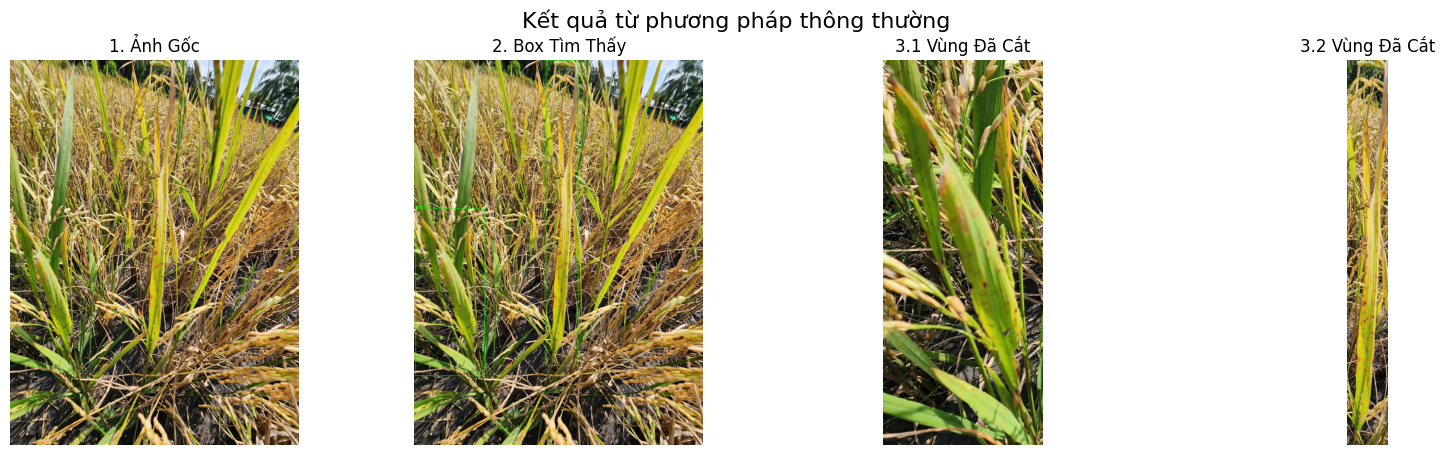

In [9]:
import os
import cv2
import numpy as np
from ultralytics import YOLO
import matplotlib.pyplot as plt

# ==============================================================================
# CẤU HÌNH - BẠN HÃY THAY ĐỔI CÁC GIÁ TRỊ NÀY
# ==============================================================================
# Đường dẫn đến mô hình YOLO (.pt) đã huấn luyện của bạn
YOLO_MODEL_PATH = "/content/drive/MyDrive/data/yolo_lan_2/best (2).pt"

# Đường dẫn đến file ảnh gốc bạn muốn thử nghiệm
TEST_IMAGE_PATH = "/content/drive/MyDrive/data/model_gk/z7114146557142_861ab2bb88aa64ca57674bb132786ff7.jpg"

# Ngưỡng tin cậy để giữ lại một bounding box
CONFIDENCE_THRESHOLD = 0.25

# ==============================================================================

def crop_detected_objects(image, boxes):
    """
    Hàm này nhận vào một ảnh và các bounding box,
    sau đó cắt và trả về một danh sách các ảnh nhỏ (các vùng được crop).
    """
    cropped_images = []
    if len(boxes) == 0:
        return cropped_images

    for box in boxes:
        x1, y1, x2, y2 = map(int, box[:4])
        # Cắt ảnh theo tọa độ box
        cropped = image[y1:y2, x1:x2]
        cropped_images.append(cropped)

    return cropped_images

def draw_boxes(image, boxes, color=(0, 255, 0)):
    """Hàm tiện ích để vẽ các bounding box lên ảnh."""
    for box in boxes:
        x1, y1, x2, y2, conf, cls = box
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cv2.rectangle(image, (x1, y1), (x2, y2), color, 2)
        label = f"Conf: {conf:.2f}"
        cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return image

def main_visualize_workflow():
    """
    Hàm chính thực hiện quy trình: phát hiện, cắt và chỉ hiển thị kết quả.
    """
    print("Bắt đầu quy trình phát hiện và hiển thị ảnh...")

    # Tải mô hình và ảnh
    try:
        model = YOLO(YOLO_MODEL_PATH)
        original_image = cv2.imread(TEST_IMAGE_PATH)
        if original_image is None: raise FileNotFoundError(f"Không tìm thấy ảnh tại {TEST_IMAGE_PATH}")
    except Exception as e:
        print(f"[Lỗi] Không thể tải mô hình hoặc ảnh: {e}")
        return

    # --------------------------------------------------------------------------
    # BƯỚC 1: DỰ ĐOÁN THÔNG THƯỜNG TRÊN TOÀN BỘ ẢNH
    # --------------------------------------------------------------------------
    print("\n--- 1. Chạy dự đoán thông thường...")
    results_standard = model(original_image, conf=CONFIDENCE_THRESHOLD, verbose=False)
    boxes_standard = results_standard[0].boxes.data.cpu().numpy()

    if len(boxes_standard) > 0:
        print(f"-> THÀNH CÔNG: Tìm thấy {len(boxes_standard)} vật thể. Đang cắt và hiển thị...")

        # Cắt các đối tượng để hiển thị
        cropped_images = crop_detected_objects(original_image, boxes_standard)

        # Vẽ box lên ảnh để hiển thị
        image_with_boxes = draw_boxes(original_image.copy(), boxes_standard)

        # Hiển thị kết quả
        num_plots = 2 + len(cropped_images)
        plt.figure(figsize=(5 * num_plots, 5))

        plt.subplot(1, num_plots, 1)
        plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
        plt.title('1. Ảnh Gốc')
        plt.axis('off')

        plt.subplot(1, num_plots, 2)
        plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
        plt.title('2. Box Tìm Thấy')
        plt.axis('off')

        for i, cropped_img in enumerate(cropped_images):
            plt.subplot(1, num_plots, 3 + i)
            plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB))
            plt.title(f'3.{i+1} Vùng Đã Cắt')
            plt.axis('off')

        plt.suptitle("Kết quả từ phương pháp thông thường", fontsize=16)
        plt.show()

    else:
        # --------------------------------------------------------------------------
        # BƯỚC 2: "CHẾ ĐỘ GIẢI CỨU" - CẮT NGANG VÀ XỬ LÝ
        # --------------------------------------------------------------------------
        print("\n--- THẤT BẠI: Không tìm thấy vật thể. Chuyển sang phương pháp 'Cắt Ngang'...")

        # Cắt ảnh
        height, width, _ = original_image.shape
        mid_point_y = height // 2
        top_half = original_image[:mid_point_y, :]
        bottom_half = original_image[mid_point_y:, :]

        # --- Xử lý nửa trên ---
        print("\n--- Xử lý nửa ảnh TRÊN...")
        results_top = model(top_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
        boxes_top = results_top[0].boxes.data.cpu().numpy()

        if len(boxes_top) > 0:
            print(f"-> Phát hiện {len(boxes_top)} vật thể ở nửa trên. Đang hiển thị...")
            cropped_top_images = crop_detected_objects(top_half, boxes_top)
            top_half_with_boxes = draw_boxes(top_half.copy(), boxes_top)

            # Hiển thị kết quả cho nửa trên
            num_plots_top = 1 + len(cropped_top_images)
            plt.figure(figsize=(5 * num_plots_top, 5))
            plt.subplot(1, num_plots_top, 1); plt.imshow(cv2.cvtColor(top_half_with_boxes, cv2.COLOR_BGR2RGB)); plt.title(f'Nửa Trên (Tìm thấy: {len(boxes_top)})'); plt.axis('off')
            for i, cropped_img in enumerate(cropped_top_images):
                plt.subplot(1, num_plots_top, 2 + i); plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)); plt.title(f'Vùng Cắt {i+1} (Trên)'); plt.axis('off')
            plt.suptitle("Kết quả 'Cắt Ngang' - Nửa Trên", fontsize=16)
            plt.show()
        else:
            print("-> Không phát hiện vật thể ở nửa trên.")

        # --- Xử lý nửa dưới ---
        print("\n--- Xử lý nửa ảnh DƯỚI...")
        results_bottom = model(bottom_half, conf=CONFIDENCE_THRESHOLD, verbose=False)
        boxes_bottom = results_bottom[0].boxes.data.cpu().numpy()

        if len(boxes_bottom) > 0:
            print(f"-> Phát hiện {len(boxes_bottom)} vật thể ở nửa dưới. Đang hiển thị...")
            cropped_bottom_images = crop_detected_objects(bottom_half, boxes_bottom)
            bottom_half_with_boxes = draw_boxes(bottom_half.copy(), boxes_bottom)

            # Hiển thị kết quả cho nửa dưới
            num_plots_bottom = 1 + len(cropped_bottom_images)
            plt.figure(figsize=(5 * num_plots_bottom, 5))
            plt.subplot(1, num_plots_bottom, 1); plt.imshow(cv2.cvtColor(bottom_half_with_boxes, cv2.COLOR_BGR2RGB)); plt.title(f'Nửa Dưới (Tìm thấy: {len(boxes_bottom)})'); plt.axis('off')
            for i, cropped_img in enumerate(cropped_bottom_images):
                plt.subplot(1, num_plots_bottom, 2 + i); plt.imshow(cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)); plt.title(f'Vùng Cắt {i+1} (Dưới)'); plt.axis('off')
            plt.suptitle("Kết quả 'Cắt Ngang' - Nửa Dưới", fontsize=16)
            plt.show()
        else:
            print("-> Không phát hiện vật thể ở nửa dưới.")

# Chạy hàm chính
main_visualize_workflow()